In [3]:
import requests
import pandas as pd

# 1. Khai báo thông tin API
country_code = 'BR'
years = [2016, 2017, 2018]
all_holidays = []

# 2. Lặp qua từng năm để gọi API Nager.Date
for year in years:
    url = f"https://date.nager.at/api/v3/PublicHolidays/{year}/{country_code}"
    response = requests.get(url)
    
    if response.status_code == 200:
        all_holidays.extend(response.json())
    else:
        print(f"Lỗi khi lấy dữ liệu năm {year}. Mã lỗi: {response.status_code}")

# 3. Chuyển đổi dữ liệu JSON sang Pandas DataFrame
df = pd.DataFrame(all_holidays)

# 4. Tiền xử lý và lọc thời gian
df['date'] = pd.to_datetime(df['date'])

start_date = pd.to_datetime('2016-09-01')
end_date = pd.to_datetime('2018-10-31')

mask = (df['date'] >= start_date) & (df['date'] <= end_date)
filtered_holidays = df.loc[mask].reset_index(drop=True)

# 5. Hiển thị kết quả (Đã sửa 'type' thành 'types')
print(f"Tổng số ngày lễ tìm thấy: {len(filtered_holidays)}")
display(filtered_holidays[['date', 'localName', 'name', 'types']])

# 6. Lưu dữ liệu ra file CSV
csv_filename = "brazil_holidays_2016_2018.csv"
filtered_holidays.to_csv(csv_filename, index=False, encoding='utf-8-sig')
print(f"Đã lưu dữ liệu thành công vào file: {csv_filename}")

Tổng số ngày lễ tìm thấy: 30


,date,localName,name,types
0,2016-09-07,Dia da Independência,Independence Day,[Public]
1,2016-10-12,Nossa Senhora Aparecida,Our Lady of Aparecida,[Public]
2,2016-11-02,Dia de Finados,All Souls' Day,[Public]
3,2016-11-15,Proclamação da República,Republic Proclamation Day,[Public]
4,2016-12-25,Natal,Christmas Day,[Public]
5,2017-01-01,Confraternização Universal,New Year's Day,[Public]
6,2017-02-27,Carnaval,Carnival,"[Bank, Optional]"
7,2017-02-28,Carnaval,Carnival,"[Bank, Optional]"
8,2017-04-14,Sexta-feira Santa,Good Friday,[Public]
9,2017-04-16,Domingo de Páscoa,Easter Sunday,[Public]


Đã lưu dữ liệu thành công vào file: brazil_holidays_2016_2018.csv


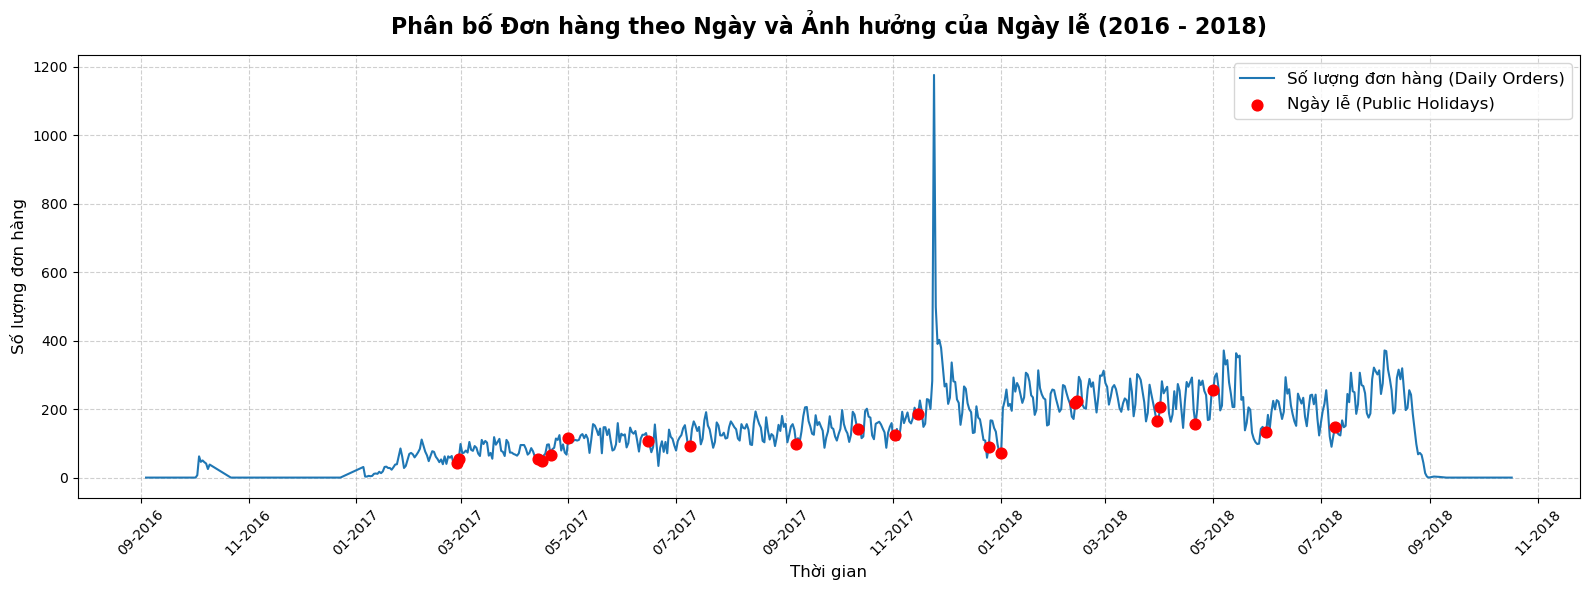

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. Đọc dữ liệu
# Đọc file đơn hàng
orders = pd.read_csv('olist_orders_dataset.csv')
# Đọc file ngày lễ đã lưu trước đó
holidays = pd.read_csv('brazil_holidays_2016_2018.csv')

# 2. Tiền xử lý dữ liệu Đơn hàng (Orders)
# Chuyển đổi thời gian mua hàng sang kiểu datetime
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
# Trích xuất phần Ngày (bỏ qua giờ/phút)
orders['order_date'] = orders['order_purchase_timestamp'].dt.date

# Gom nhóm theo ngày và đếm số lượng đơn hàng
daily_orders = orders.groupby('order_date').size().reset_index(name='order_count')
# Chuyển lại cột 'order_date' sang datetime để dễ vẽ biểu đồ
daily_orders['order_date'] = pd.to_datetime(daily_orders['order_date'])

# 3. Tiền xử lý dữ liệu Ngày lễ (Holidays)
holidays['date'] = pd.to_datetime(holidays['date'])

# Kết hợp (Merge) dữ liệu đơn hàng và ngày lễ để lấy số lượng đơn vào đúng ngày lễ đó
holiday_orders = pd.merge(daily_orders, holidays, left_on='order_date', right_on='date', how='inner')

# 4. Vẽ biểu đồ
plt.figure(figsize=(16, 6))

# Vẽ đường xu hướng số lượng đơn hàng mỗi ngày
plt.plot(daily_orders['order_date'], daily_orders['order_count'], 
         color='#1f77b4', linewidth=1.5, label='Số lượng đơn hàng (Daily Orders)')

# Đánh dấu các ngày lễ bằng các điểm màu đỏ
plt.scatter(holiday_orders['order_date'], holiday_orders['order_count'], 
            color='red', s=60, zorder=5, label='Ngày lễ (Public Holidays)')

# Định dạng biểu đồ
plt.title('Phân bố Đơn hàng theo Ngày và Ảnh hưởng của Ngày lễ (2016 - 2018)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Thời gian', fontsize=12)
plt.ylabel('Số lượng đơn hàng', fontsize=12)

# Định dạng trục X để hiển thị theo tháng - năm
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)

# Thêm lưới và chú thích
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)
plt.tight_layout()

# Hiển thị biểu đồ
plt.show()

C:\Users\Msi\AppData\Local\Temp\ipykernel_37956\1112671432.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_holiday', y='order_count', data=df_analysis, palette='Set2')


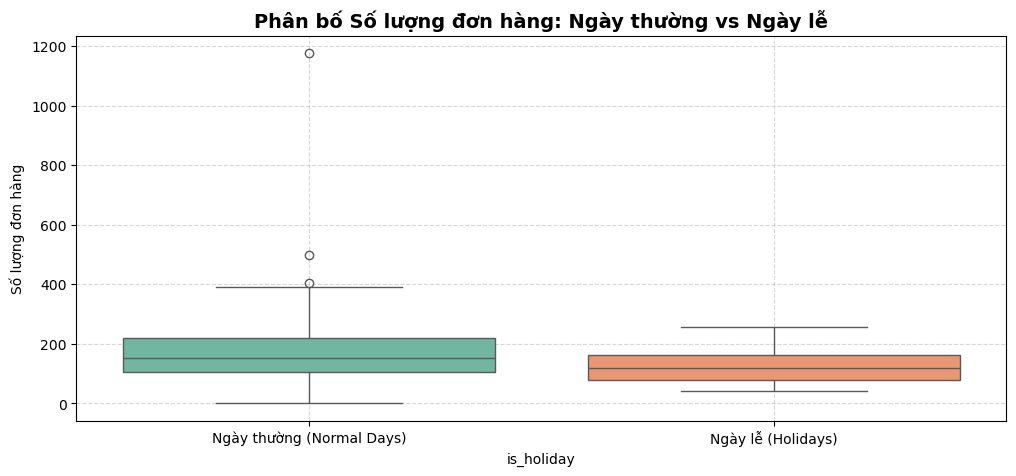

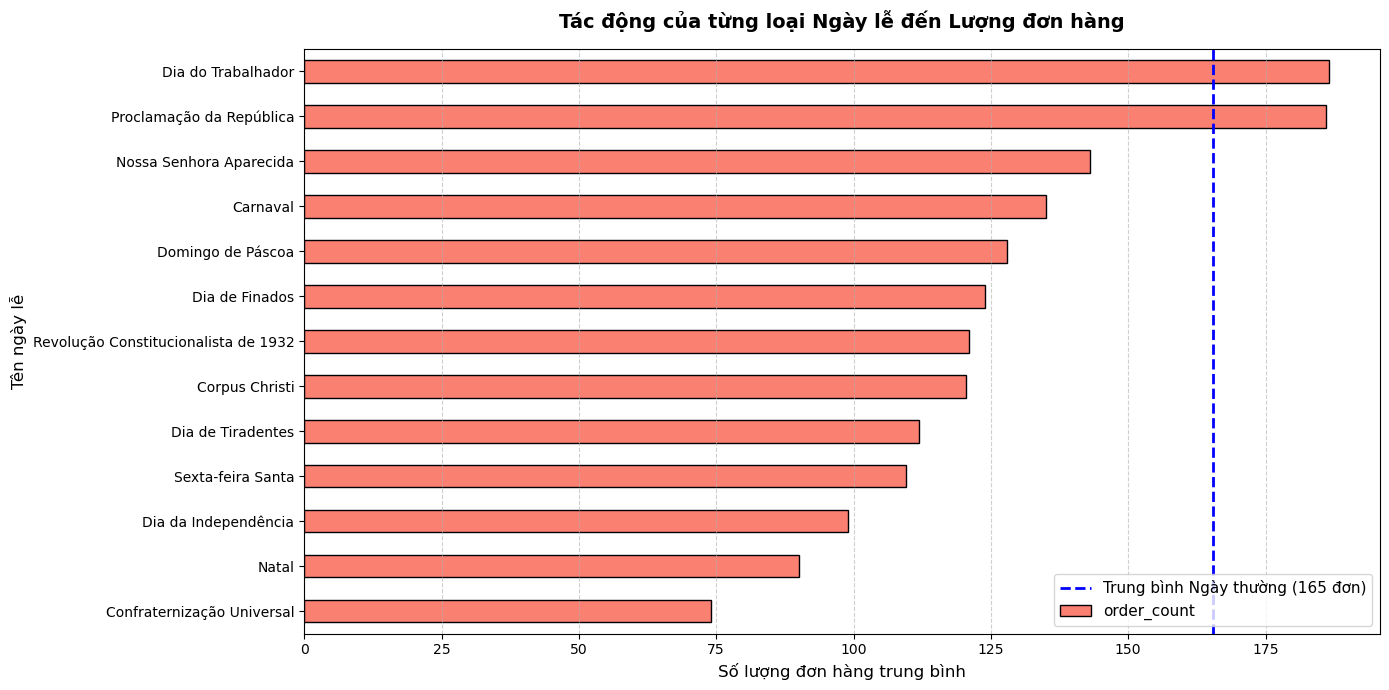

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Giả định bạn đã có DataFrame daily_orders và holidays từ đoạn code trước
# 1. Lọc phần dữ liệu ổn định (01/2017 - 08/2018)
clean_orders = daily_orders[(daily_orders['order_date'] >= pd.to_datetime('2017-01-01')) & 
                            (daily_orders['order_date'] <= pd.to_datetime('2018-08-31'))].copy()

# 2. Gắn nhãn và kết hợp dữ liệu
# Merge bằng left join để giữ lại toàn bộ ngày thường
df_analysis = clean_orders.merge(holidays[['date', 'localName', 'types']], 
                                 left_on='order_date', right_on='date', how='left')

# Tạo cột phân loại (True nếu là ngày lễ, False nếu là ngày thường)
df_analysis['is_holiday'] = df_analysis['date'].notnull()

# Tính trung bình ngày thường để làm đường cơ sở (Baseline)
normal_days_avg = df_analysis[~df_analysis['is_holiday']]['order_count'].mean()

# 3. Vẽ biểu đồ Boxplot phân bố tổng thể
plt.figure(figsize=(12, 5))
sns.boxplot(x='is_holiday', y='order_count', data=df_analysis, palette='Set2')
plt.title('Phân bố Số lượng đơn hàng: Ngày thường vs Ngày lễ', fontsize=14, fontweight='bold')
plt.xticks([0, 1], ['Ngày thường (Normal Days)', 'Ngày lễ (Holidays)'])
plt.ylabel('Số lượng đơn hàng')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 4. Vẽ biểu đồ phân loại theo Từng Ngày Lễ (Impact Analysis)
# Tính trung bình đơn hàng cho từng sự kiện
holiday_impact = df_analysis[df_analysis['is_holiday']].groupby('localName')['order_count'].mean().sort_values()

plt.figure(figsize=(14, 7))
holiday_impact.plot(kind='barh', color='salmon', edgecolor='black')

# Vẽ đường trung bình của ngày thường
plt.axvline(x=normal_days_avg, color='blue', linestyle='--', linewidth=2, 
            label=f'Trung bình Ngày thường ({normal_days_avg:.0f} đơn)')

plt.title('Tác động của từng loại Ngày lễ đến Lượng đơn hàng', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Số lượng đơn hàng trung bình', fontsize=12)
plt.ylabel('Tên ngày lễ', fontsize=12)
plt.legend(fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [27]:
import pandas as pd

# 1. Cập nhật danh sách sự kiện (Thêm Christmas Leadup)
commercial_events = {
    'Black_Friday_Week_2017': pd.date_range(start='2017-11-20', end='2017-11-27'),
    'Consumer_Week_2017': pd.date_range(start='2017-03-10', end='2017-03-15'),
    'Consumer_Week_2018': pd.date_range(start='2018-03-10', end='2018-03-15'),
    'Mothers_Day_Leadup_2017': pd.date_range(start='2017-05-07', end='2017-05-13'),
    'Mothers_Day_Leadup_2018': pd.date_range(start='2018-05-06', end='2018-05-12'),
    'Dia_dos_Namorados_Leadup_2017': pd.date_range(start='2017-06-05', end='2017-06-11'),
    'Dia_dos_Namorados_Leadup_2018': pd.date_range(start='2018-06-05', end='2018-06-11'),
    # Thêm mùa mua sắm trước Giáng Sinh 2017 (10/12 đến 24/12)
    'Christmas_Leadup_2017': pd.date_range(start='2017-12-10', end='2017-12-24') 
}

# Tạo list chứa tất cả Timestamp của Sự kiện Thương mại và Dictionary tra cứu tên
all_event_dates = []
date_to_event = {}
for event_name, dates in commercial_events.items():
    all_event_dates.extend(dates)
    for d in dates:
        date_to_event[d] = event_name

# 2. Chuyển cột date của Ngày lễ sang tập hợp (Set) để tìm phần giao (Intersection)
holiday_dates_set = set(holidays['date'])
event_dates_set = set(all_event_dates)

# Tìm các ngày trùng lặp (Overlap)
overlap_dates = event_dates_set.intersection(holiday_dates_set)

# 3. Báo cáo kết quả kiểm tra
print("=== KẾT QUẢ KIỂM TRA XUNG ĐỘT DỮ LIỆU ===")
if overlap_dates:
    print(f"⚠️ CẢNH BÁO: Phát hiện {len(overlap_dates)} ngày bị trùng lặp giữa Ngày lễ và Sự kiện!\n")
    for d in sorted(overlap_dates):
        event_name = date_to_event[d]
        holiday_name = holidays[holidays['date'] == d]['localName'].values[0]
        print(f"- Ngày {d.strftime('%d/%m/%Y')}: Đang bị gắn nhãn '{event_name}' NHƯNG lại trùng Ngày lễ '{holiday_name}'")
else:
    print("✅ TIN VUI: Không có sự giao thoa (overlap) nào giữa Sự kiện Thương mại và Ngày lễ trong dữ liệu của bạn.")

# 4. Gán lại nhãn dữ liệu chuẩn vào DataFrame
# (Chú ý: Trong hàm này, nếu có Overlap xảy ra, điều kiện nào nằm TRÊN sẽ được ưu tiên)
df_analysis['is_commercial_event'] = df_analysis['order_date'].isin(all_event_dates).astype(int)

def resolve_and_categorize(row):
    # ƯU TIÊN 1: Sự kiện Thương mại (Vì nó tác động mạnh đến sales hơn)
    if row.get('is_commercial_event') == 1:
        return 'Sự kiện Thương mại'
    # ƯU TIÊN 2: Ngày lễ
    elif row.get('is_holiday') == True:
        return 'Ngày Lễ'
    else:
        return 'Ngày Thường'

df_analysis['day_type'] = df_analysis.apply(resolve_and_categorize, axis=1)
df_analysis['event_name'] = df_analysis['order_date'].map(date_to_event)

=== KẾT QUẢ KIỂM TRA XUNG ĐỘT DỮ LIỆU ===
✅ TIN VUI: Không có sự giao thoa (overlap) nào giữa Sự kiện Thương mại và Ngày lễ trong dữ liệu của bạn.


BẢNG THỐNG KÊ SỐ LƯỢNG ĐƠN HÀNG THEO LOẠI NGÀY:


,Số_ngày,Trung_bình,Trung_vị,Cao_nhất
day_type,,,,
Ngày Lễ,22,128.0,120.0,256
Ngày Thường,519,160.0,151.0,380
Sự kiện Thương mại,63,207.0,193.0,1176


C:\Users\Msi\AppData\Local\Temp\ipykernel_37956\2402350211.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='day_type', y='order_count', data=df_analysis,


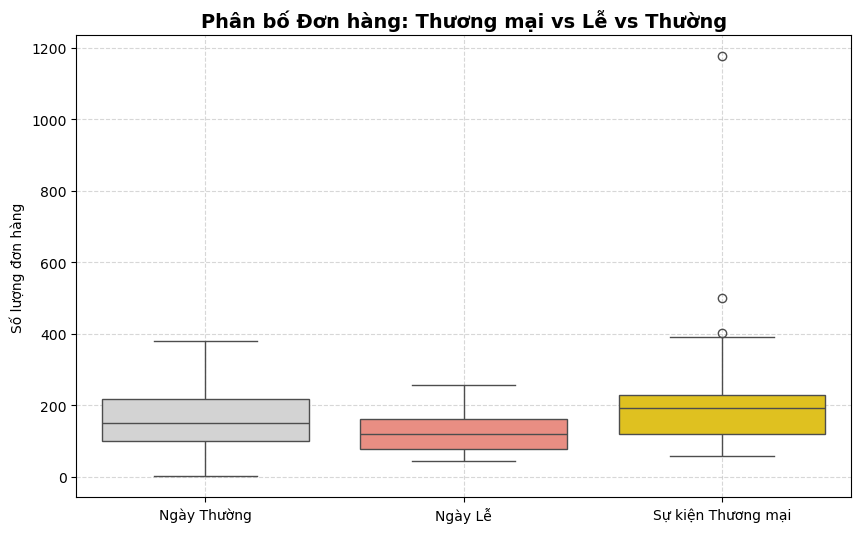

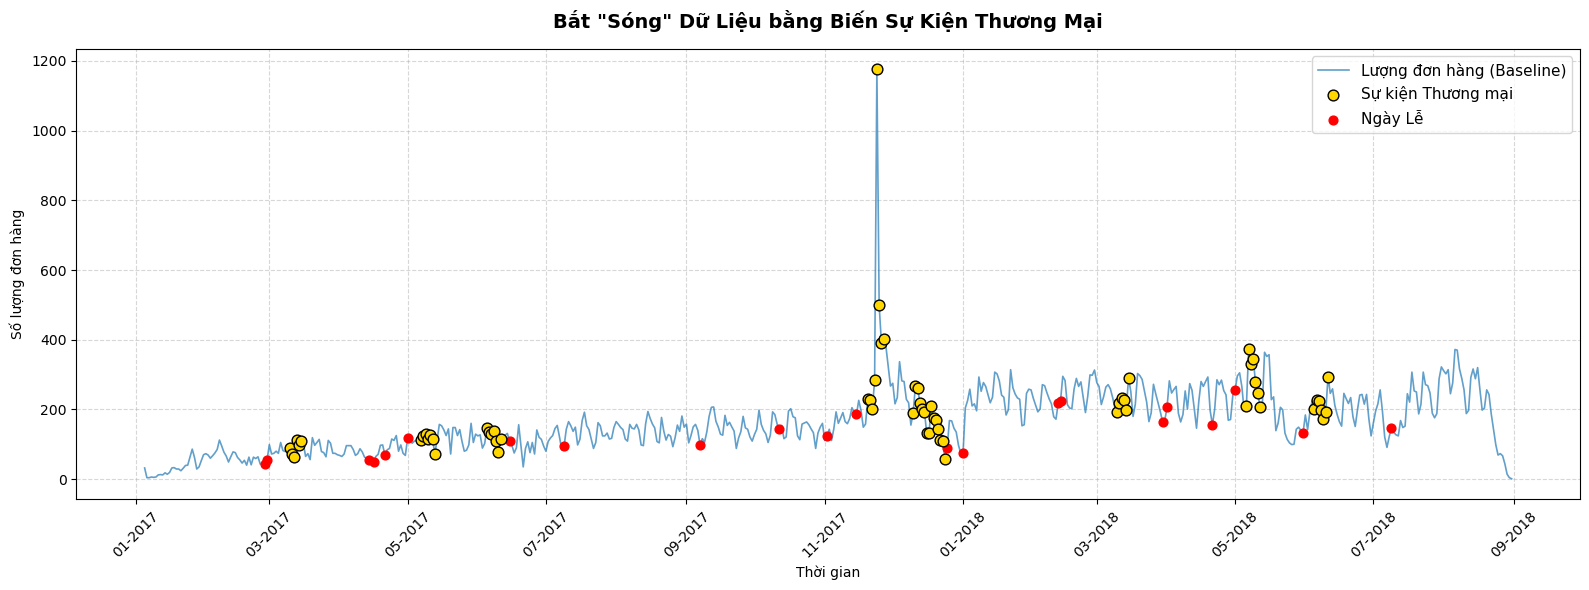

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# Giả định df_analysis của bạn đã được map cột 'is_holiday' và 'is_commercial_event'
# 1. Tạo một cột phân loại tổng hợp (day_type) để dễ so sánh
def categorize_day(row):
    if row.get('is_commercial_event') == 1:
        return 'Sự kiện Thương mại'
    elif row.get('is_holiday') == True:
        return 'Ngày Lễ'
    else:
        return 'Ngày Thường'

df_analysis['day_type'] = df_analysis.apply(categorize_day, axis=1)

# 2. In bảng thống kê tổng quan
summary_stats = df_analysis.groupby('day_type')['order_count'].agg(
    Số_ngày='count', 
    Trung_bình='mean', 
    Trung_vị='median', 
    Cao_nhất='max'
).round(0)

print("BẢNG THỐNG KÊ SỐ LƯỢNG ĐƠN HÀNG THEO LOẠI NGÀY:")
display(summary_stats)

# 3. Vẽ Boxplot so sánh phân bố
plt.figure(figsize=(10, 6))
sns.boxplot(x='day_type', y='order_count', data=df_analysis, 
            palette={'Ngày Thường': 'lightgray', 'Ngày Lễ': 'salmon', 'Sự kiện Thương mại': 'gold'})
plt.title('Phân bố Đơn hàng: Thương mại vs Lễ vs Thường', fontsize=14, fontweight='bold')
plt.ylabel('Số lượng đơn hàng')
plt.xlabel('')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 4. Vẽ biểu đồ đường chẩn đoán (Diagnostic Line Chart)
plt.figure(figsize=(16, 6))
# Vẽ nền ngày thường
plt.plot(df_analysis['order_date'], df_analysis['order_count'], 
         color='#1f77b4', linewidth=1.2, alpha=0.7, label='Lượng đơn hàng (Baseline)')

# Đánh dấu Sự kiện Thương mại (Màu vàng)
com_events = df_analysis[df_analysis['day_type'] == 'Sự kiện Thương mại']
plt.scatter(com_events['order_date'], com_events['order_count'], 
            color='gold', s=60, edgecolors='black', zorder=5, label='Sự kiện Thương mại')

# (Tùy chọn) Đánh dấu Ngày lễ (Màu đỏ) để thấy rõ sự tương phản
holidays = df_analysis[df_analysis['day_type'] == 'Ngày Lễ']
plt.scatter(holidays['order_date'], holidays['order_count'], 
            color='red', s=40, zorder=4, label='Ngày Lễ')

plt.title('Bắt "Sóng" Dữ Liệu bằng Biến Sự Kiện Thương Mại', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Thời gian')
plt.ylabel('Số lượng đơn hàng')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%Y'))
plt.xticks(rotation=45)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

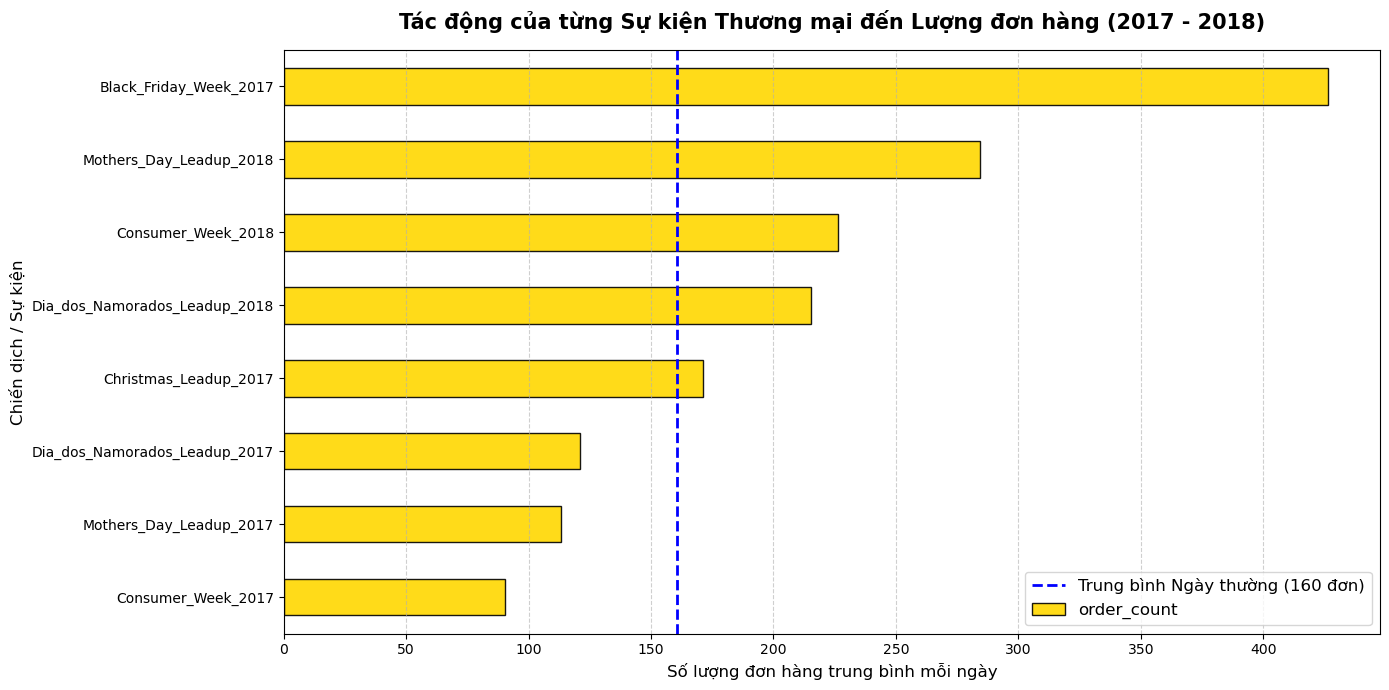

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Tạo Dictionary ánh xạ ngược: Từ Ngày cụ thể -> Tên Sự kiện
date_to_event = {}
for event_name, dates in commercial_events.items():
    for d in dates:
        date_to_event[d] = event_name

# 2. Map Tên sự kiện vào DataFrame
# Tạo cột mới 'event_name', nếu ngày đó không có sự kiện thì sẽ là NaN (Not a Number)
df_analysis['event_name'] = df_analysis['order_date'].map(date_to_event)

# 3. Tính toán tác động của từng sự kiện
# Lọc ra các ngày có sự kiện (bỏ qua NaN) và tính trung bình số đơn
event_impact = df_analysis.dropna(subset=['event_name']).groupby('event_name')['order_count'].mean().sort_values()

# Tính trung bình ngày thường (không lễ, không sự kiện) để làm Baseline
normal_days_avg = df_analysis[df_analysis['day_type'] == 'Ngày Thường']['order_count'].mean()

# 4. Trực quan hóa bằng Bar Chart
plt.figure(figsize=(14, 7))
event_impact.plot(kind='barh', color='gold', edgecolor='black', alpha=0.9)

# Vẽ đường cơ sở (Baseline) của Ngày thường
plt.axvline(x=normal_days_avg, color='blue', linestyle='--', linewidth=2, 
            label=f'Trung bình Ngày thường ({normal_days_avg:.0f} đơn)')

# Định dạng biểu đồ
plt.title('Tác động của từng Sự kiện Thương mại đến Lượng đơn hàng (2017 - 2018)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Số lượng đơn hàng trung bình mỗi ngày', fontsize=12)
plt.ylabel('Chiến dịch / Sự kiện', fontsize=12)
plt.legend(fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()

# Hiển thị biểu đồ
plt.show()

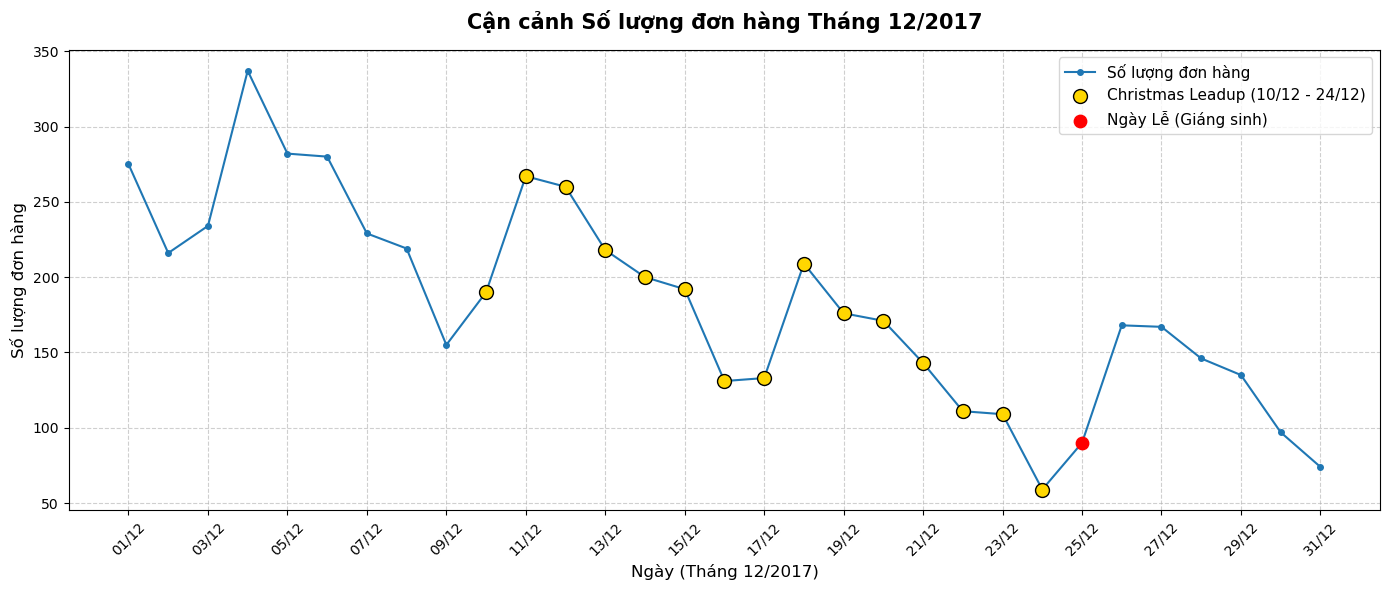

In [33]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# 1. Lọc dữ liệu riêng cho tháng 12 năm 2017
start_dec = pd.to_datetime('2017-12-01')
end_dec = pd.to_datetime('2017-12-31')
df_dec_2017 = df_analysis[(df_analysis['order_date'] >= start_dec) & (df_analysis['order_date'] <= end_dec)]

# 2. Vẽ biểu đồ
plt.figure(figsize=(14, 6))

# Vẽ đường xu hướng chung
plt.plot(df_dec_2017['order_date'], df_dec_2017['order_count'], 
         marker='o', markersize=4, linestyle='-', color='#1f77b4', linewidth=1.5, label='Số lượng đơn hàng')

# Đánh dấu các ngày thuộc Christmas Leadup (Mùa mua sắm Giáng sinh)
christmas_sales = df_dec_2017[df_dec_2017['event_name'] == 'Christmas_Leadup_2017']
if not christmas_sales.empty:
    plt.scatter(christmas_sales['order_date'], christmas_sales['order_count'], 
                color='gold', s=100, edgecolors='black', zorder=5, label='Christmas Leadup (10/12 - 24/12)')

# Đánh dấu Ngày lễ chính thức (Giáng sinh 25/12)
holidays_dec = df_dec_2017[df_dec_2017['day_type'] == 'Ngày Lễ']
if not holidays_dec.empty:
    plt.scatter(holidays_dec['order_date'], holidays_dec['order_count'], 
                color='red', s=80, zorder=5, label='Ngày Lễ (Giáng sinh)')

# 3. Định dạng biểu đồ
plt.title('Cận cảnh Số lượng đơn hàng Tháng 12/2017', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Ngày (Tháng 12/2017)', fontsize=12)
plt.ylabel('Số lượng đơn hàng', fontsize=12)

# Định dạng trục X hiển thị từng ngày
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.xticks(rotation=45)

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()

# Hiển thị biểu đồ
plt.show()

người mua Brazil dồn đơn sớm hơn nhiều so với giả định "leadup sát ngày lễ" — cao điểm thực sự nằm ở đầu tháng 12 (thậm chí có thể nối liền với đuôi sóng Black Friday cuối tháng 11), rồi giảm dần vì họ biết giao hàng chậm, đặt trễ sẽ không kịp Giáng sinh. Khung ngày bạn chọn (10–24/12) vô tình bắt đúng đoạn dốc xuống chứ không phải đoạn cao điểm.

In [36]:
import pandas as pd
import numpy as np

# ==========================================
# 1. CẬP NHẬT LẠI TỪ ĐIỂN SỰ KIỆN THƯƠNG MẠI
# ==========================================
commercial_events = {
    'Black_Friday_Week_2017': pd.date_range(start='2017-11-20', end='2017-11-27'),
    'Consumer_Week_2017': pd.date_range(start='2017-03-10', end='2017-03-15'),
    'Consumer_Week_2018': pd.date_range(start='2018-03-10', end='2018-03-15'),
    'Mothers_Day_Leadup_2017': pd.date_range(start='2017-05-07', end='2017-05-13'),
    'Mothers_Day_Leadup_2018': pd.date_range(start='2018-05-06', end='2018-05-12'),
    'Dia_dos_Namorados_Leadup_2017': pd.date_range(start='2017-06-05', end='2017-06-11'),
    'Dia_dos_Namoradoss_Leadup_2018': pd.date_range(start='2018-06-05', end='2018-06-11'),
    
    # [MỚI] Điều chỉnh giai đoạn Giáng sinh 2017
    'Christmas_Shopping_Peak_2017': pd.date_range(start='2017-11-28', end='2017-12-08'),
    'Pre_Christmas_Shipping_Cutoff_2017': pd.date_range(start='2017-12-10', end='2017-12-24')
}

# Ánh xạ lại Tên sự kiện vào DataFrame
all_event_dates = []
date_to_event = {}
for event_name, dates in commercial_events.items():
    all_event_dates.extend(dates)
    for d in dates:
        date_to_event[d] = event_name

df_analysis['is_commercial_event'] = df_analysis['order_date'].isin(all_event_dates).astype(int)
df_analysis['event_name'] = df_analysis['order_date'].map(date_to_event)

# Cập nhật lại day_type (Ưu tiên Sự kiện > Ngày lễ)
def resolve_day_type(row):
    if row.get('is_commercial_event') == 1:
        return 'Commercial_Event'
    elif row.get('is_holiday') == True:
        return 'Public_Holiday'
    else:
        return 'Normal_Day'

df_analysis['day_type'] = df_analysis.apply(resolve_day_type, axis=1)
# Hợp nhất tên Ngày lễ và Tên Sự kiện vào chung 1 cột để dễ phân tích
df_analysis['specific_event_name'] = df_analysis['event_name'].fillna(df_analysis['localName'])

# ==========================================
# 2. XÂY DỰNG HỆ THỐNG TIER BẰNG % CHÊNH LỆCH
# ==========================================

# Tính Baseline của Ngày thường
baseline_avg = df_analysis[df_analysis['day_type'] == 'Normal_Day']['order_count'].mean()

# Nhóm dữ liệu và tính % chênh lệch
impact_df = df_analysis.dropna(subset=['specific_event_name']).groupby('specific_event_name').agg(
    avg_orders=('order_count', 'mean'),
    event_type=('day_type', 'first')
).reset_index()

impact_df['pct_vs_baseline'] = ((impact_df['avg_orders'] - baseline_avg) / baseline_avg) * 100

# Hàm phân loại Tier chuẩn bị cho mô hình dự báo
def assign_impact_tier(pct):
    if pct >= 50:
        return 'Tier_1_Mega_Boost'      # Tăng trưởng đột biến (>50%)
    elif 15 <= pct < 50:
        return 'Tier_2_High_Boost'      # Tăng trưởng tốt (15% - 50%)
    elif -15 <= pct < 15:
        return 'Tier_3_Neutral'         # Không ảnh hưởng đáng kể (+/- 15%)
    elif -50 <= pct < -15:
        return 'Tier_4_Mild_Drop'       # Sụt giảm vừa phải (-15% đến -50%)
    else:
        return 'Tier_5_Severe_Drop'     # Đóng băng giao dịch (< -50%)

impact_df['impact_tier'] = impact_df['pct_vs_baseline'].apply(assign_impact_tier)

# Hiển thị bảng tổng hợp để kiểm tra
print(f"Mức nền Ngày thường (Baseline): {baseline_avg:.0f} đơn/ngày\n")
display(impact_df.sort_values(by='pct_vs_baseline', ascending=False).round(2))

# ==========================================
# 3. MAPPING NGƯỢC TIER VÀO DATAFRAME CHÍNH
# ==========================================
# Tạo dictionary để map nhanh từ tên sự kiện sang tier
tier_mapping = dict(zip(impact_df['specific_event_name'], impact_df['impact_tier']))

# Map vào data gốc (Ngày thường sẽ được gán là Tier_3_Neutral)
df_analysis['final_impact_tier'] = df_analysis['specific_event_name'].map(tier_mapping).fillna('Tier_3_Neutral')

Mức nền Ngày thường (Baseline): 158 đơn/ngày



,specific_event_name,avg_orders,event_type,pct_vs_baseline,impact_tier
0,Black_Friday_Week_2017,426.38,Commercial_Event,170.00,Tier_1_Mega_Boost
15,Mothers_Day_Leadup_2018,284.43,Commercial_Event,80.11,Tier_1_Mega_Boost
2,Christmas_Shopping_Peak_2017,276.55,Commercial_Event,75.12,Tier_1_Mega_Boost
5,Consumer_Week_2018,226.50,Commercial_Event,43.43,Tier_2_High_Boost
12,Dia_dos_Namoradoss_Leadup_2018,215.29,Commercial_Event,36.33,Tier_2_High_Boost
10,Dia do Trabalhador,186.50,Public_Holiday,18.10,Tier_2_High_Boost
19,Proclamação da República,186.00,Public_Holiday,17.78,Tier_2_High_Boost
18,Pre_Christmas_Shipping_Cutoff_2017,171.27,Commercial_Event,8.45,Tier_3_Neutral
17,Nossa Senhora Aparecida,143.00,Public_Holiday,-9.45,Tier_3_Neutral
1,Carnaval,135.00,Public_Holiday,-14.51,Tier_3_Neutral


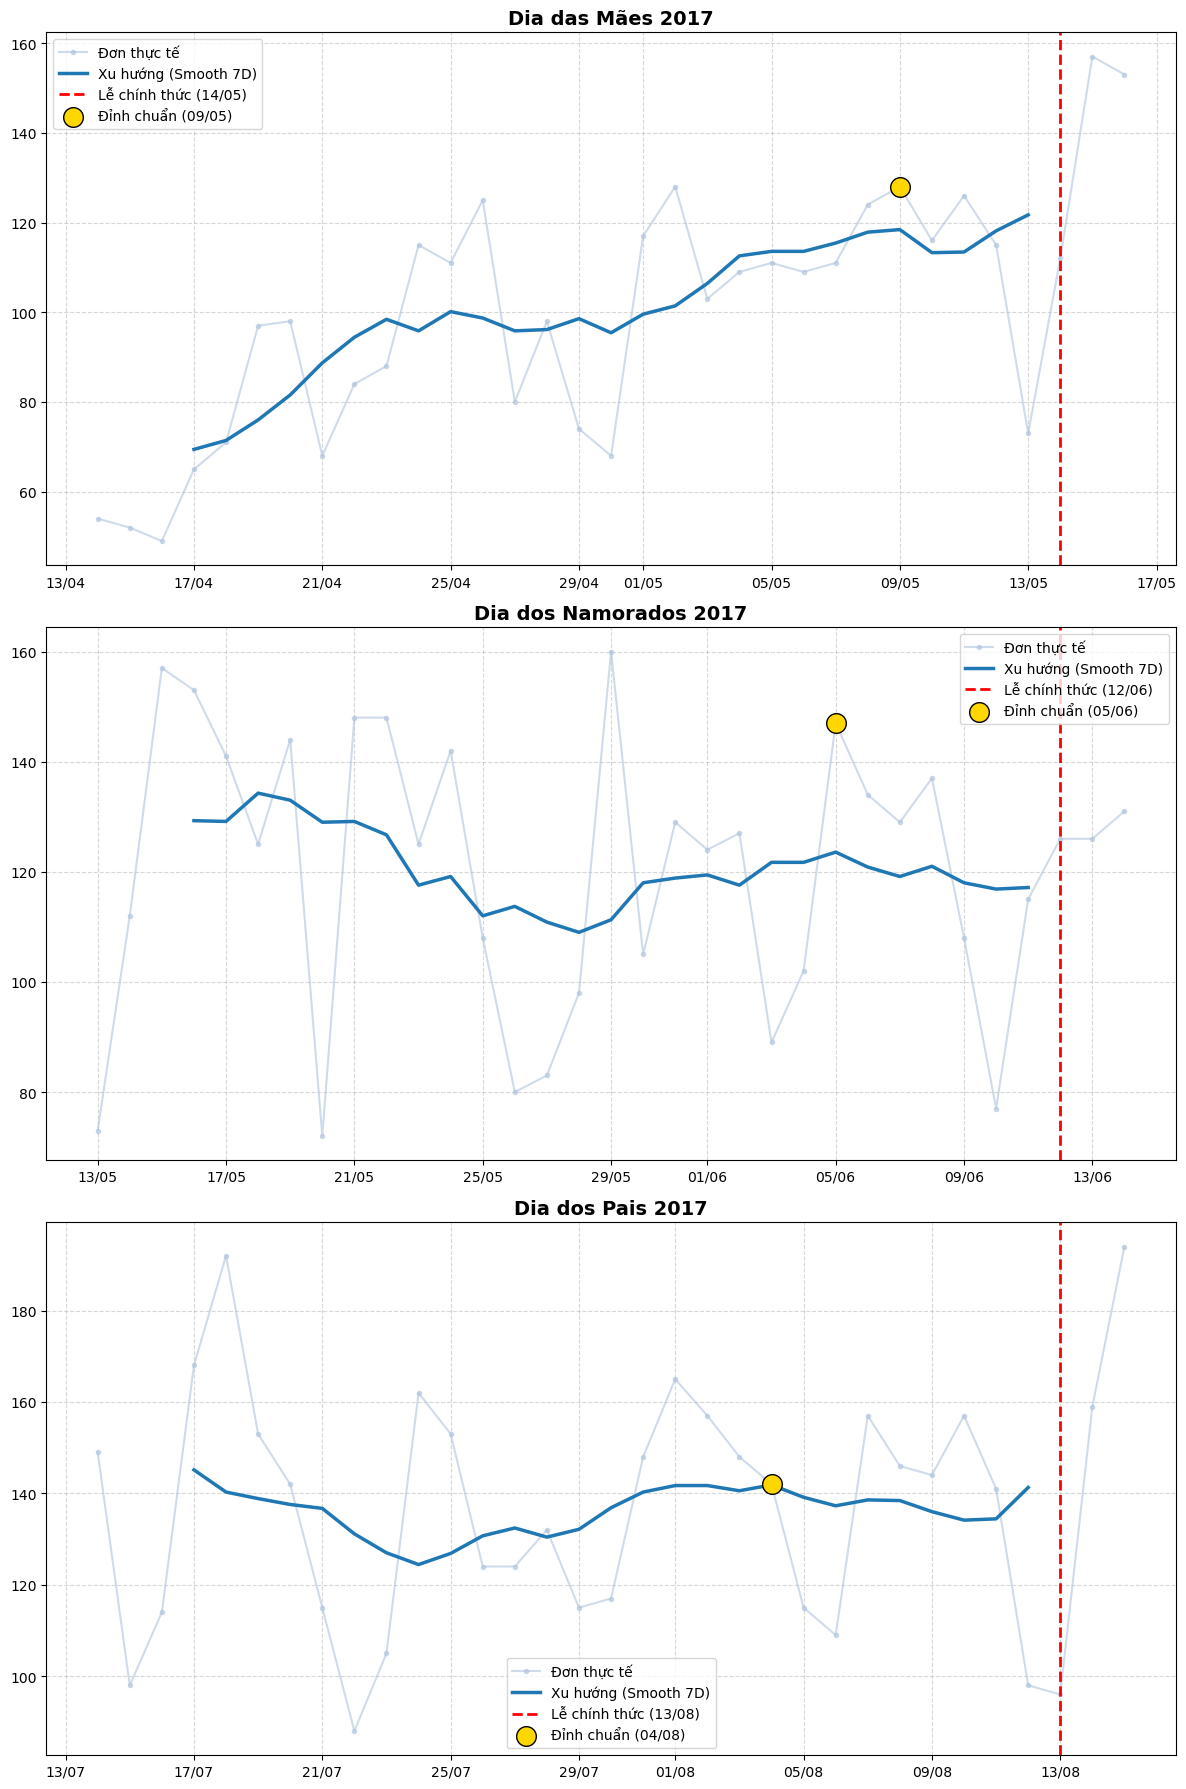

In [50]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

target_holidays = [
    {'name': "Dia das Mães 2017", 'date': '2017-05-14'},
    {'name': "Dia dos Namorados 2017", 'date': '2017-06-12'},
    {'name': "Dia dos Pais 2017", 'date': '2017-08-13'}
]

fig, axes = plt.subplots(3, 1, figsize=(12, 18))

for i, event in enumerate(target_holidays):
    target_date = pd.to_datetime(event['date'])
    ax = axes[i]
    
    window_start = target_date - pd.Timedelta(days=30)
    window_end = target_date + pd.Timedelta(days=2)
    
    df_window = df_analysis[(df_analysis['order_date'] >= window_start) & 
                            (df_analysis['order_date'] <= window_end)].copy()
    
    df_window['smoothed_count'] = df_window['order_count'].rolling(window=7, center=True).mean()
    
    # [ĐIỀU CHỈNH QUAN TRỌNG]: Chỉ cho phép tìm đỉnh trong khoảng từ 3 đến 15 ngày trước ngày lễ
    # Tránh việc máy với tay ra xa bắt nhầm các đỉnh nhiễu đầu tháng
    search_start = target_date - pd.Timedelta(days=15)
    search_end = target_date - pd.Timedelta(days=3)
    
    search_area = df_window[(df_window['order_date'] >= search_start) & 
                            (df_window['order_date'] <= search_end)]
    
    peak_row = search_area.loc[search_area['smoothed_count'].idxmax()]
    
    # Vẽ biểu đồ
    ax.plot(df_window['order_date'], df_window['order_count'], color='#b0c4de', marker='o', markersize=3, alpha=0.6, label='Đơn thực tế')
    ax.plot(df_window['order_date'], df_window['smoothed_count'], color='#1f77b4', linewidth=2.5, label='Xu hướng (Smooth 7D)')
    ax.axvline(x=target_date, color='red', linestyle='--', linewidth=2, label=f"Lễ chính thức ({target_date.strftime('%d/%m')})")
    
    ax.scatter(peak_row['order_date'], peak_row['order_count'], color='gold', s=200, edgecolors='black', zorder=5, 
               label=f"Đỉnh chuẩn ({peak_row['order_date'].strftime('%d/%m')})")
    
    ax.set_title(event['name'], fontsize=14, fontweight='bold')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

Dia das Mães 2017 (Ngày của Mẹ - 14/05): Đỉnh chốt đơn đạt vào 09/05 (trước lễ 5 ngày). Giai đoạn tăng trưởng bắt đầu từ đầu tháng 5 và cắm đầu giảm mạnh vào 3-4 ngày sát lễ do vướng ngưỡng cắt giảm vận chuyển (shipping cutoff).

Dia dos Namorados 2017 (Valentine - 12/06): Đỉnh chuẩn khóa chặt vào 05/06 (trước lễ 7 ngày). Đường xu hướng bám rất sát nhịp tăng từ cuối tháng 5 và hạ nhiệt đúng lúc khách hàng không thể đợi hàng giao kịp ngày.

Dia dos Pais 2017 (Ngày của Cha - 13/08): Đỉnh xu hướng nằm ở ngày 04/08 (trước lễ 9 ngày). Khoảng cách này phản ánh chính xác thời gian vận chuyển trung bình (lead time) dài hơn đối với các mặt hàng quà tặng cho nam giới hoặc khu vực logistics phức tạp hơn.

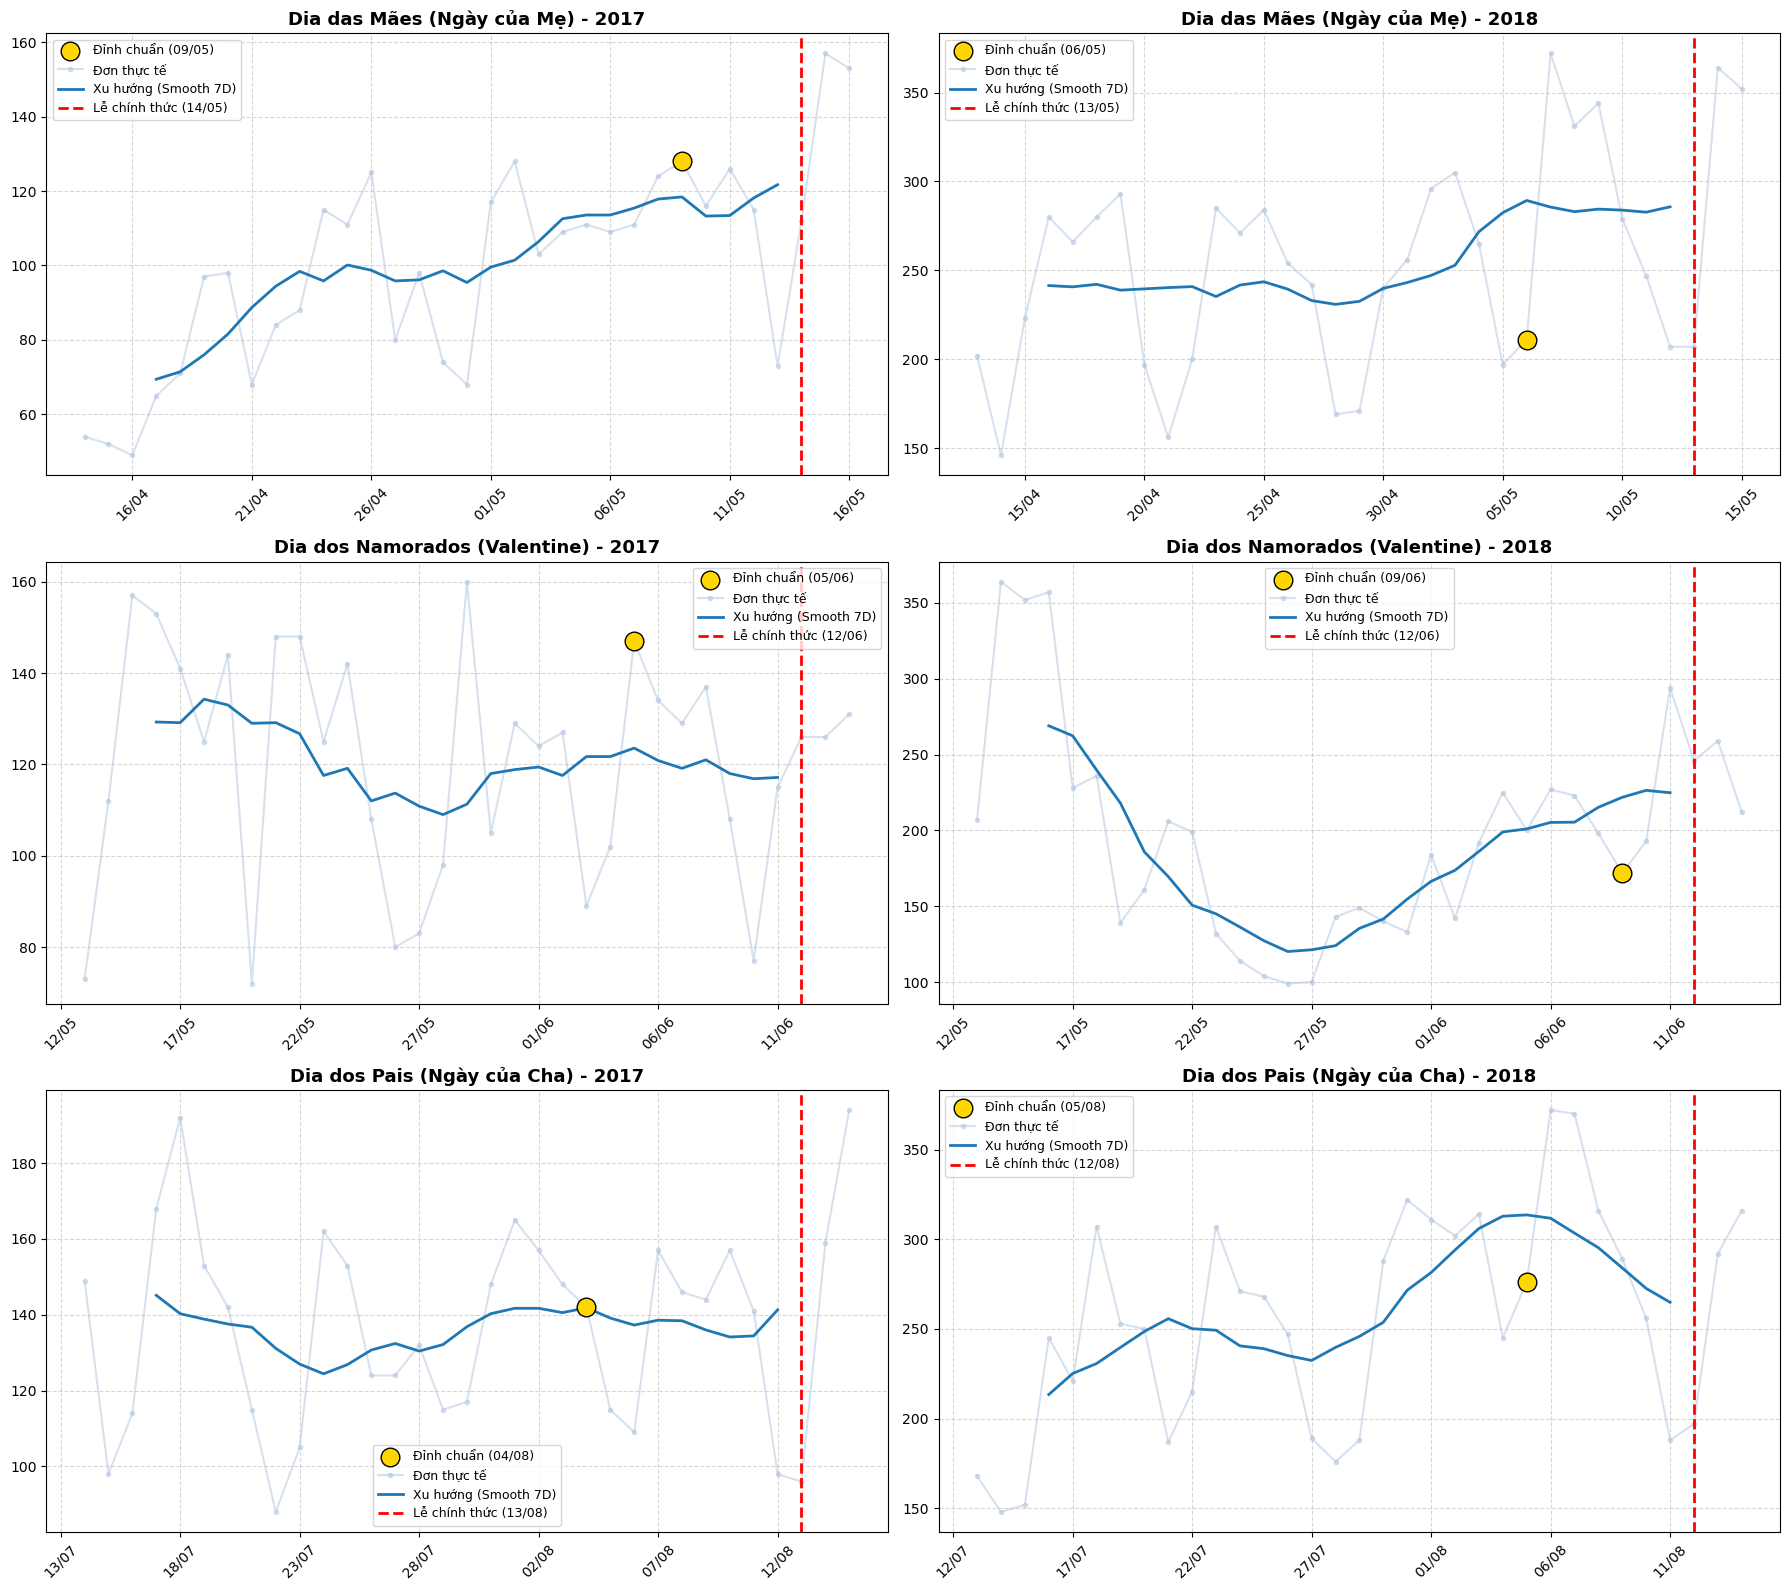

In [59]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Khai báo danh sách các cặp sự kiện qua 2 năm (2017 & 2018)
events_to_compare = [
    {'name': "Dia das Mães (Ngày của Mẹ)", '2017': '2017-05-14', '2018': '2018-05-13'},
    {'name': "Dia dos Namorados (Valentine)", '2017': '2017-06-12', '2018': '2018-06-12'},
    {'name': "Dia dos Pais (Ngày của Cha)", '2017': '2017-08-13', '2018': '2018-08-12'}
]

# Tạo khung vẽ lưới (3 hàng x 2 cột cho 3 sự kiện x 2 năm)
fig, axes = plt.subplots(3, 2, figsize=(18, 16))

for row_idx, event in enumerate(events_to_compare):
    years = ['2017', '2018']
    
    for col_idx, year in enumerate(years):
        ax = axes[row_idx, col_idx]
        target_date = pd.to_datetime(event[year])
        
        # Cửa sổ 30 ngày trước lễ đến 2 ngày sau lễ
        window_start = target_date - pd.Timedelta(days=30)
        window_end = target_date + pd.Timedelta(days=2)
        
        df_window = df_analysis[(df_analysis['order_date'] >= window_start) & 
                                (df_analysis['order_date'] <= window_end)].copy()
        
        # Khử nhiễu bằng trung bình trượt 7 ngày
        df_window['smoothed_count'] = df_window['order_count'].rolling(window=7, center=True).mean()
        
        # Vùng tìm kiếm đỉnh: từ 15 ngày đến 3 ngày trước lễ
        search_start = target_date - pd.Timedelta(days=15)
        search_end = target_date - pd.Timedelta(days=3)
        search_area = df_window[(df_window['order_date'] >= search_start) & 
                                (df_window['order_date'] <= search_end)]
        
        if not search_area.empty and search_area['smoothed_count'].notna().any():
            peak_row = search_area.loc[search_area['smoothed_count'].idxmax()]
            
            # Vẽ điểm đỉnh chuẩn
            ax.scatter(peak_row['order_date'], peak_row['order_count'], color='gold', s=180, edgecolors='black', zorder=5, 
                       label=f"Đỉnh chuẩn ({peak_row['order_date'].strftime('%d/%m')})")
        
        # Vẽ biểu đồ
        ax.plot(df_window['order_date'], df_window['order_count'], color='#b0c4de', marker='o', markersize=3, alpha=0.5, label='Đơn thực tế')
        ax.plot(df_window['order_date'], df_window['smoothed_count'], color='#1f77b4', linewidth=2, label='Xu hướng (Smooth 7D)')
        ax.axvline(x=target_date, color='red', linestyle='--', linewidth=2, label=f"Lễ chính thức ({target_date.strftime('%d/%m')})")
        
        ax.set_title(f"{event['name']} - {year}", fontsize=13, fontweight='bold')
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=5))
        ax.tick_params(axis='x', rotation=45)
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


    # Các sự kiện thương mại chung
    'Black_Friday_Week_2017': pd.date_range(start='2017-11-20', end='2017-11-27'),
    'Consumer_Week_2017': pd.date_range(start='2017-03-10', end='2017-03-15'),
    'Consumer_Week_2018': pd.date_range(start='2018-03-10', end='2018-03-15'),
    
    # Ngày của Mẹ (Peak & Cutoff dựa trên quét xu hướng thực tế)
    'Mothers_Day_Peak_2017': pd.date_range(start='2017-04-30', end='2017-05-09'),
    'Mothers_Day_Cutoff_2017': pd.date_range(start='2017-05-10', end='2017-05-14'),
    'Mothers_Day_Peak_2018': pd.date_range(start='2018-04-25', end='2018-05-05'),
    'Mothers_Day_Cutoff_2018': pd.date_range(start='2018-05-06', end='2018-05-13'),
    
    # Valentine (Dia dos Namorados)
    'Dia dos Namorados_Peak_2017': pd.date_range(start='2017-05-28', end='2017-06-05'),
    'Dia dos Namorados_Cutoff_2017': pd.date_range(start='2017-06-06', end='2017-06-12'),
    'Dia dos Namorados_Peak_2018': pd.date_range(start='2018-05-28', end='2018-06-06'),
    'Dia dos Namorados_Cutoff_2018': pd.date_range(start='2018-06-07', end='2018-06-12'),
    
    # Ngày của Cha (Dia dos Pais)
    'Fathers_Day_Peak_2017': pd.date_range(start='2017-07-25', end='2017-08-04'),
    'Fathers_Day_Cutoff_2017': pd.date_range(start='2017-08-05', end='2017-08-13'),
    'Fathers_Day_Peak_2018': pd.date_range(start='2018-07-25', end='2018-08-05'),
    'Fathers_Day_Cutoff_2018': pd.date_range(start='2018-08-06', end='2018-08-12'),
    
    # Mùa Giáng sinh chuẩn hóa
    'Christmas_Shopping_Peak_2017': pd.date_range(start='2017-11-25', end='2017-12-08'),
    'Pre_Christmas_Shipping_Cutoff_2017': pd.date_range(start='2017-12-10', end='2017-12-24')